In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
import warnings
warnings.filterwarnings('ignore')

# Charger le CSV
df = pd.read_csv('patients_cancer_poumon.csv', sep=';')
print(f"Shape: {df.shape}")
df.head()

Shape: (184, 20)


,patient_id,age,sexe_masculin,presence_nodule,subtilite_nodule,taille_nodule_px,x_nodule_norm,y_nodule_norm,tabagisme_paquets_annee,toux_chronique,dyspnee,douleur_thoracique,perte_poids,spo2,antecedent_familial,risque_malignite,classe_jsrt_source,diagnostic_source,cancer_image,image_path
0,JPCLN001,53,1,1,5,1,0.7979,0.3379,34.9,1,1,1,1,92,0,2,malin,malignant,1,jsrt_subset/malin/JPCLN001.jpg
1,JPCLN002,78,0,1,5,1,0.7881,0.5322,31.4,1,0,0,0,95,0,1,benin,benign,0,jsrt_subset/benin/JPCLN002.jpg
2,JPCLN003,63,0,1,5,1,0.6362,0.2183,34.9,1,1,1,1,92,1,2,malin,malignant,1,jsrt_subset/malin/JPCLN003.jpg
3,JPCLN004,68,0,1,5,1,0.2959,0.4082,28.4,1,0,0,0,95,0,1,benin,benign,0,jsrt_subset/benin/JPCLN004.jpg
4,JPCLN005,73,0,1,5,1,0.7021,0.3379,37.9,1,1,1,1,92,1,2,malin,malignant,1,jsrt_subset/malin/JPCLN005.jpg


In [9]:
# Types des variables et valeurs manquantes
print("=== Types des variables ===")
print(df.dtypes)
print("\n=== Valeurs manquantes ===")
print(df.isnull().sum())
print("\n=== Statistiques descriptives ===")
df.describe()

=== Types des variables ===
patient_id                     str
age                          int64
sexe_masculin                int64
presence_nodule              int64
subtilite_nodule             int64
taille_nodule_px             int64
x_nodule_norm              float64
y_nodule_norm              float64
tabagisme_paquets_annee    float64
toux_chronique               int64
dyspnee                      int64
douleur_thoracique           int64
perte_poids                  int64
spo2                         int64
antecedent_familial          int64
risque_malignite             int64
classe_jsrt_source             str
diagnostic_source              str
cancer_image                 int64
image_path                     str
dtype: object

=== Valeurs manquantes ===
patient_id                 0
age                        0
sexe_masculin              0
presence_nodule            0
subtilite_nodule           0
taille_nodule_px           0
x_nodule_norm              0
y_nodule_norm              

,age,sexe_masculin,presence_nodule,subtilite_nodule,taille_nodule_px,x_nodule_norm,y_nodule_norm,tabagisme_paquets_annee,toux_chronique,dyspnee,douleur_thoracique,perte_poids,spo2,antecedent_familial,risque_malignite,cancer_image
count,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000
mean,59.331522,0.456522,0.836957,2.581522,0.836957,0.383059,0.354977,30.212500,0.836957,0.543478,0.543478,0.543478,93.858696,0.320652,1.380435,0.543478
std,12.770521,0.499465,0.370413,1.286281,0.370413,0.280274,0.224145,7.769606,0.370413,0.499465,0.499465,0.499465,2.254717,0.468001,0.751572,0.499465
min,21.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,9.000000,0.000000,0.000000,0.000000,0.000000,92.000000,0.000000,0.000000,0.000000
25%,51.000000,0.000000,1.000000,1.000000,1.000000,0.212925,0.195300,24.500000,1.000000,0.000000,0.000000,0.000000,92.000000,0.000000,1.000000,0.000000
50%,61.000000,0.000000,1.000000,3.000000,1.000000,0.289050,0.357900,31.400000,1.000000,1.000000,1.000000,1.000000,92.000000,0.000000,2.000000,1.000000
75%,69.000000,1.000000,1.000000,4.000000,1.000000,0.700675,0.520000,36.175000,1.000000,1.000000,1.000000,1.000000,95.000000,1.000000,2.000000,1.000000
max,80.000000,1.000000,1.000000,5.000000,1.000000,0.868200,0.828100,43.000000,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,2.000000,1.000000


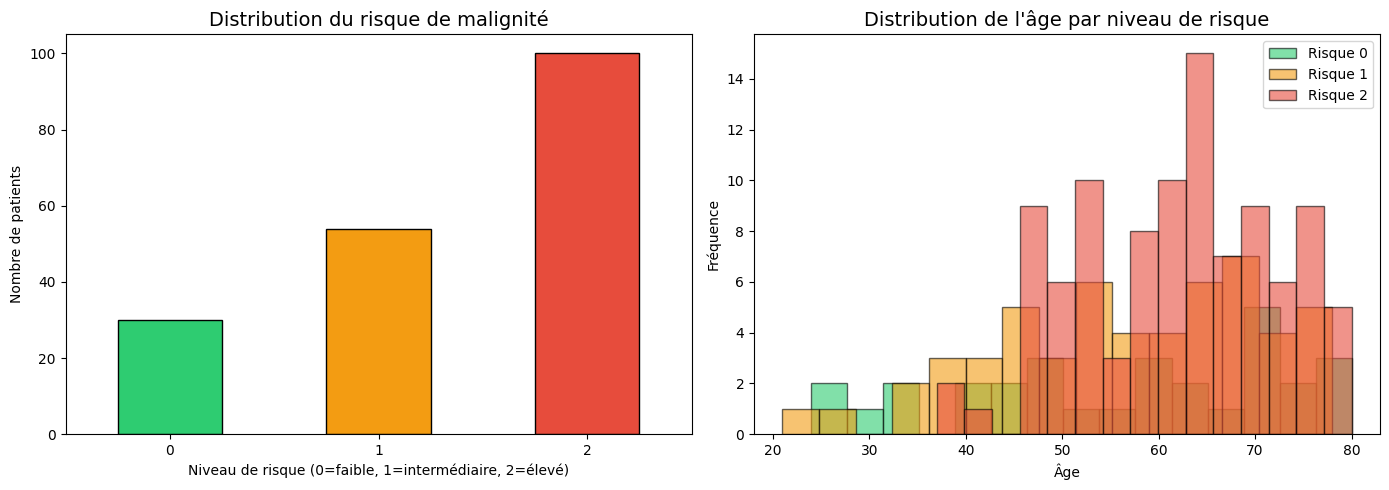

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Visualisation 1 : Distribution du risque de malignité
colors = ['#2ecc71', '#f39c12', '#e74c3c']
df['risque_malignite'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=colors, edgecolor='black'
)
axes[0].set_title('Distribution du risque de malignité', fontsize=14)
axes[0].set_xlabel('Niveau de risque (0=faible, 1=intermédiaire, 2=élevé)')
axes[0].set_ylabel('Nombre de patients')
axes[0].tick_params(axis='x', rotation=0)

# Visualisation 2 : Distribution de l'âge par risque
for i, risk in enumerate([0, 1, 2]):
    subset = df[df['risque_malignite'] == risk]['age']
    axes[1].hist(subset, bins=15, alpha=0.6, label=f'Risque {risk}', color=colors[i], edgecolor='black')
axes[1].set_title("Distribution de l'âge par niveau de risque", fontsize=14)
axes[1].set_xlabel('Âge')
axes[1].set_ylabel('Fréquence')
axes[1].legend()

plt.tight_layout()
plt.show()

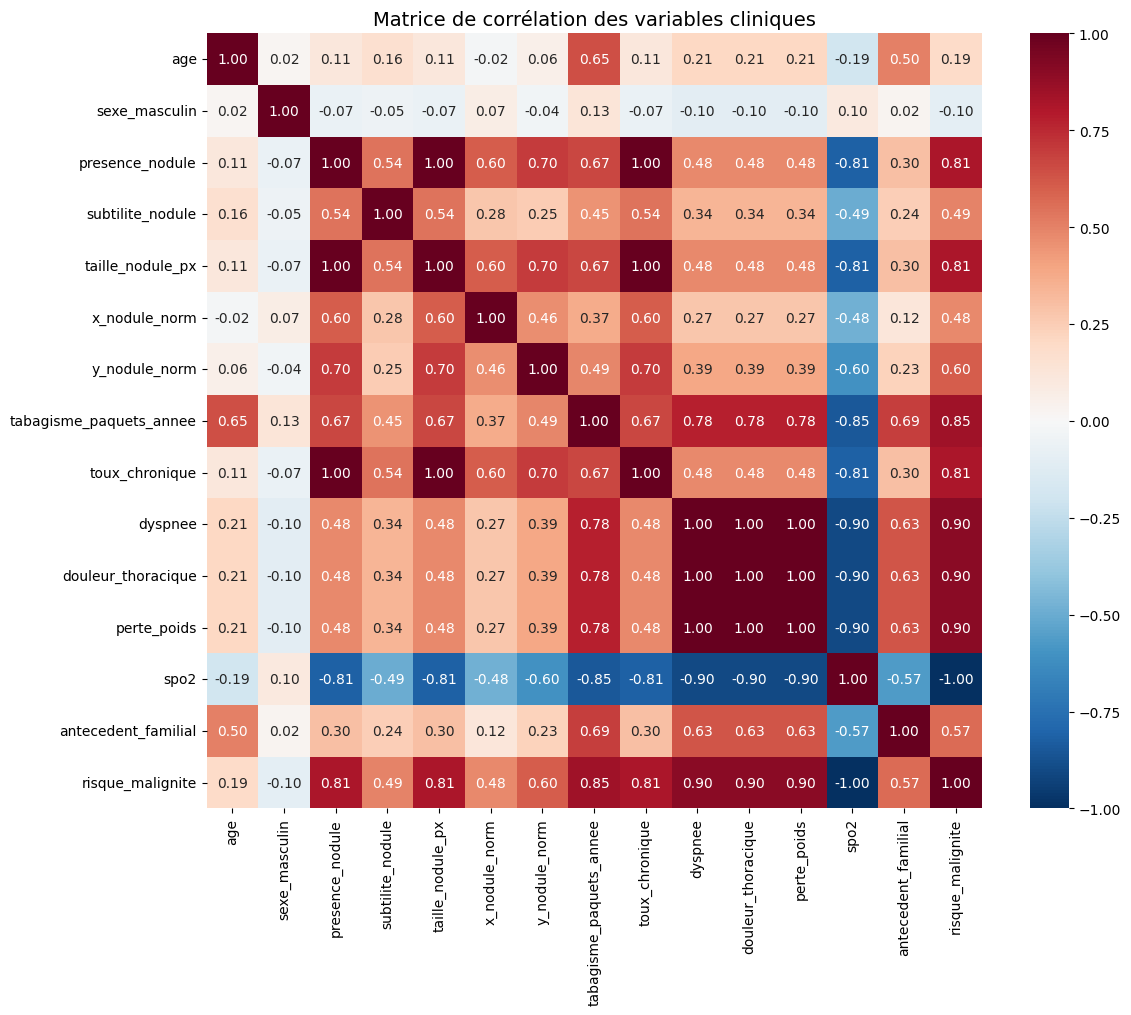

In [11]:
# Sélectionner les colonnes numériques pertinentes
cols_num = ['age', 'sexe_masculin', 'presence_nodule', 'subtilite_nodule',
            'taille_nodule_px', 'x_nodule_norm', 'y_nodule_norm',
            'tabagisme_paquets_annee', 'toux_chronique', 'dyspnee',
            'douleur_thoracique', 'perte_poids', 'spo2',
            'antecedent_familial', 'risque_malignite']

plt.figure(figsize=(12, 10))
sns.heatmap(df[cols_num].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True)
plt.title('Matrice de corrélation des variables cliniques', fontsize=14)
plt.tight_layout()
plt.show()

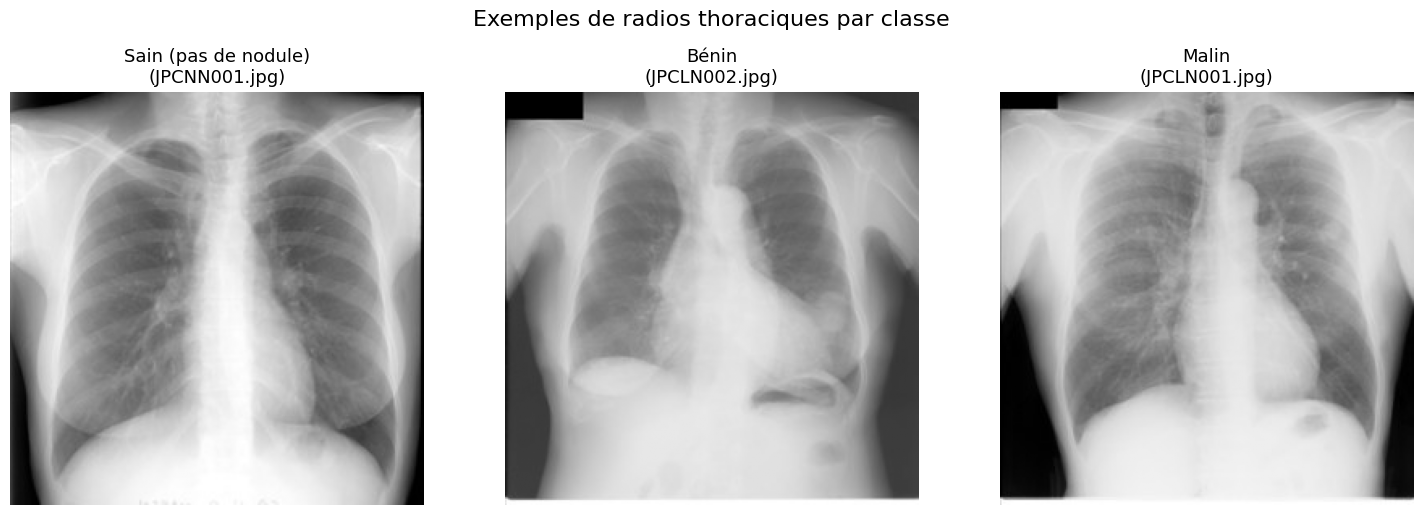

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
classes = ['sain', 'benin', 'malin']
titles = ['Sain (pas de nodule)', 'Bénin', 'Malin']

for i, (cls, title) in enumerate(zip(classes, titles)):
    folder = f'jsrt_subset/{cls}'
    img_name = os.listdir(folder)[0]
    img = Image.open(os.path.join(folder, img_name))
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'{title}\n({img_name})', fontsize=13)
    axes[i].axis('off')

plt.suptitle('Exemples de radios thoraciques par classe', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()